In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create the datasets

<div style="display: flex; gap: 10px">
  <div style="width: 45%; display: flex; flex-direction: column;">
    <ul>
      <li class="fragment fade-in">Two classes</li>
      <li class="fragment fade-in">Gaussian distributions</li>
      <li class="fragment fade-in">Different means: \( m_1 = -1 \) and \( m_2 = 1 \)</li>
      <li class="fragment fade-in">Equal priors, \( P_1 = P_2 = 0.5 \)</li>
    </ul>
  </div>
  <div style="width: 45%; display: flex; flex-direction: column;">
    <ul>
        <li class="fragment fade-in">Three datasets each containing 1,000 samples per class</li>
        <li class="fragment fade-in">Same variance \( \sigma^2 \), \([0.25, 0.49, 1.00]\)</li>
      <li class="fragment fade-in">First 500 samples in each class for training and the last 500 for testing.</li>
    </ul>
  </div>
</div>


In [3]:
def generate_df(variance):
    m1 = -1
    m2 = 1
    n_samples_per_class = 1000
    sigma = np.sqrt(variance)
    train_test_size = int(n_samples_per_class/2)
    
    # Generate samples for each class
    samples_class1 = np.random.normal(loc=m1, scale=sigma, size=n_samples_per_class)
    samples_class2 = np.random.normal(loc=m2, scale=sigma, size=n_samples_per_class)
    
    # Create DataFrame for class 1
    df_class1 = pd.DataFrame({
        'Value': samples_class1,
        'Class': 1,
        'Set': ['train'] * train_test_size + ['test'] * train_test_size
    })
    
    # Create DataFrame for class 2
    df_class2 = pd.DataFrame({
        'Value': samples_class2,
        'Class': 2,
        'Set': ['train'] * train_test_size + ['test'] * train_test_size
    })
    
    # Concatenate the data for both classes into one DataFrame
    df = pd.concat([df_class1, df_class2]).reset_index(drop=True)
    return df

In [4]:
# Set the random seed for reproducibility
np.random.seed(42)

# Variance values for the three datasets
variances = [0.25, 0.49, 1.00]

# Generate the three DataFrames corresponding to the different variances
df_1 = generate_df(variances[0])
df_2 = generate_df(variances[1])
df_3 = generate_df(variances[2])

# Problem 1

## (1a) Plotting hisograms of the test sets

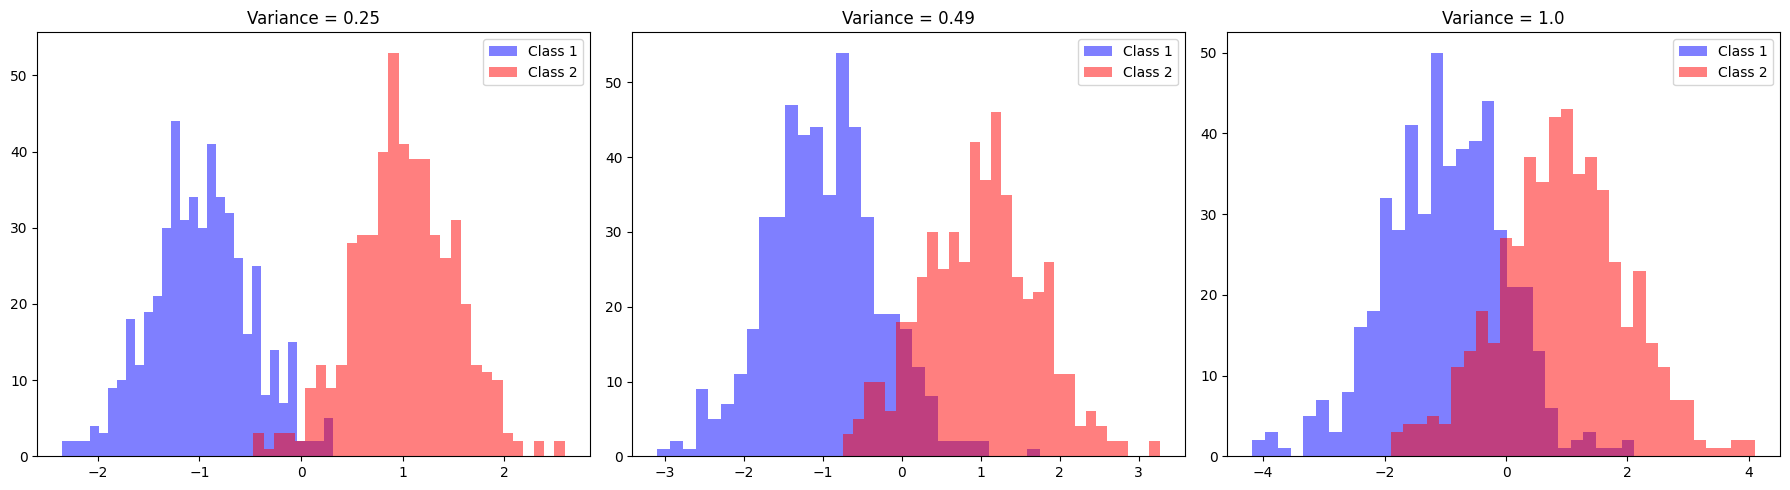

In [5]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dataframes = [df_1, df_2, df_3]

for ax, df, var in zip(axes, dataframes, variances):
    # Filter the test set samples
    df_test = df[df['Set'] == 'test']
    
    # Separate samples by class
    class1 = df_test[df_test['Class'] == 1]
    class2 = df_test[df_test['Class'] == 2]
    
    # Plot histograms for each class
    ax.hist(class1['Value'], bins=30, alpha=0.5, color='blue', label='Class 1')
    ax.hist(class2['Value'], bins=30, alpha=0.5, color='red', label='Class 2')
    
    # Set subplot title and legend
    ax.set_title(f'Variance = {var}')
    ax.legend()

plt.tight_layout()
plt.show()

We see that the dataset 3 with variance = 1 has the greatest overlap and dataset 1 the smallest. This is reasonable since a greater variance means the values can take on a larger range of values, and the error rate is thus exptected to be the greatest. 

## (1b) Assume the true class densities are known. From the theory of statisticscalculate the true error rate for the three variance cases.

Recall that we have a binary classification problem with two classes:
- **Class 1:** $x \sim \mathcal{N}(-1,\sigma^2)$
- **Class 2:** $x \sim \mathcal{N}(1,\sigma^2)$

With equal priors and variances, the optimal decision threshold is at  
$$
x = \frac{m_1 + m_2}{2} = 0,
$$

because this is the point where the likelihoods $ p(x\mid C_1) $ and $ p(x\mid C_2) $ are equal.


Thus, an error occurs if:
- A sample from **Class 1** falls in the region $x > 0$, or  
- A sample from **Class 2** falls in the region $x < 0$.

Due to symmetry the error probability for each class is identical. Focusing on **Class 1**, the error probability is

$$
P(\text{error} \mid \omega_1) = \int_{0}^{\infty} \frac{1}{\sqrt{2\pi}\,\sigma} \exp\!\left(-\frac{(x+1)^2}{2\sigma^2}\right) dx.
$$

Normalizing the previous integral using
$$
y = \frac{x+1}{\sigma}, \quad \text{so that} \quad dx = \sigma\,dy,
$$
gives us $y = \frac{1}{\sigma}$ when $x = 0$, and the integral then becomes

$$
P(\text{error} \mid \omega_1) = \frac{1}{\sqrt{2\pi}} \int_{\frac{1}{\sigma}}^{\infty} \exp\!\left(-\frac{y^2}{2}\right) dy.
$$

This is recognized as the tail probability of a standard normal distribution:

$$
\frac{1}{\sqrt{2\pi}}\int_{z}^{\infty} \exp\!\left(-\frac{y^2}{2}\right) dy = 1-\Phi(z), \qquad \text{with }z = \frac{1}{\sigma}
$$

Namely,
$$
P(\text{error} \mid \omega_1) = 1 - \Phi\!\left(z\right).
$$

Due to equal priors the overall error probability bec omes

$$
P_e = 1 - \Phi\!\left(z\right) = \frac{1}{2}\operatorname{erfc}\!\left(\frac{z}{\sqrt{2}}\right)
$$

where $\operatorname{erfc}$ is the complementary error function. In our case this gives 

$$
P_e = \frac{1}{2}\operatorname{erfc}\!\left(\frac{1}{\sigma\sqrt{2}}\right), 
$$

since we subtract $0$ and normalize by $\sigma$.

$\implies$ We want to solve $\frac{1}{2}\operatorname{erfc}\!\left(\frac{1}{\sigma\sqrt{2}}\right)$ for the three $\sigma^2$

### Compute the error rates in python

In [6]:
from scipy.stats import norm

print("True Error Rates:")
for var in variances:
    sigma = np.sqrt(var)
    # Calculate the error rate using the optimal decision boundary at x = 0
    error_rate = 1 - norm.cdf(1 / sigma)
    print(f'For varaince {var:.2f}, the error rate is: {error_rate*100:.2f} %')

True Error Rates:
For varaince 0.25, the error rate is: 2.28 %
For varaince 0.49, the error rate is: 7.66 %
For varaince 1.00, the error rate is: 15.87 %


## (1c) Implement the true density classifier

In [7]:
test_df_1 = df_1[df_1['Set'] == 'test'].copy()

def run_experiments_true_density(test_df, NT, num_experiments=5,seed=69):
    """
    For a given NT and number of experiments, the function partitions
    the test set for each class into non-overlapping groups, classifies
    the data and computes the confusion matrices and error rates.
    """
    # Shuffle the test samples for each class (using a fixed seed for reproducibility)
    test_class1 = test_df[test_df['Class'] == 1].sample(frac=1, random_state=seed).reset_index(drop=True)
    test_class2 = test_df[test_df['Class'] == 2].sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # Partition each class's test set into num_experiments groups of size NT.
    groups_class1 = [test_class1.iloc[i*NT:(i+1)*NT] for i in range(num_experiments)]
    groups_class2 = [test_class2.iloc[i*NT:(i+1)*NT] for i in range(num_experiments)]
    
    confusion_matrices = []
    error_rates = []
    
    for i in range(num_experiments):
        # Combine the NT samples from both classes for this experiment.
        exp_data = pd.concat([groups_class1[i], groups_class2[i]])
        
        # Predict using the threshold rule: if Value < 0, predict class 1; else predict class 2.
        y_true = exp_data['Class'].values
        y_pred = np.where(exp_data['Value'] < 0, 1, 2)
        
        # Compute confusion matrix using sklearn (ensuring the order of labels [1, 2])
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        confusion_matrices.append(cm)
        
        # Compute error rate.
        error_rate = np.sum(y_true != y_pred) / len(y_true)
        error_rates.append(error_rate)
    
    # Compute the average confusion matrix (element-wise average over experiments)
    avg_cm = sum(confusion_matrices) / num_experiments
    avg_error_rate = np.mean(error_rates)
    
    return confusion_matrices, error_rates, avg_cm, avg_error_rate


In [8]:
def plot_cms(confusion_matrices, error_rates, title_suffix):
    """
    Plots all confusion matrices and prints error rates for the five experiments
    """
    
    # Create a figure with 1 row and 5 columns for the 5 experiments
    fig, axes = plt.subplots(1, 5, figsize=(20, 8))
    
    for i, ax in enumerate(axes):
        im = ax.imshow(confusion_matrices[i], interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Exp {i+1}\nError rate: {error_rates[i]*100:.1f}%', fontsize=10)
        
        # Add text to the cells
        for row in range(confusion_matrices[i].shape[0]):
            for col in range(confusion_matrices[i].shape[1]):
                threshold = confusion_matrices[i].max() / 2.0
                cell_value = confusion_matrices[i][row, col]
                text_color = "white" if cell_value > threshold else "black"
                ax.text(col, row, int(cell_value), ha="center", va="center", color=text_color, fontsize=12)
        
        # Set the ticks and labels.
        ax.set_xticks(np.arange(2))
        ax.set_yticks(np.arange(2))
        ax.set_xticklabels([1, 2])
        ax.set_yticklabels([1, 2])
        ax.set_xlabel('Predicted', fontsize=10)
        if i == 0:
            ax.set_ylabel('True', fontsize=10)
        else:
            ax.set_ylabel('')

    fig.suptitle(f'Confusion Matrices for {title_suffix}', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    fig.subplots_adjust(top=1.3)

    plt.show()

In [9]:
def plot_avg_cm_all(results, title_suffix):
    """
    Plots the average confusion matrices for all NTs stored in results
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, NT in zip(axes, [5, 20, 100]):
        avg_cm = results[NT]["avg_confusion_matrix"]
        avg_err = results[NT]["avg_error_rate"]

        im = ax.imshow(avg_cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Sample size {NT}\nAvg Err: {avg_err*100:.1f}%', fontsize=12)

        # Add text to the cells
        for row in range(avg_cm.shape[0]):
            for col in range(avg_cm.shape[1]):
                threshold = avg_cm.max() / 2.0
                cell_value = avg_cm[row, col]
                text_color = "white" if cell_value > threshold else "black"
                ax.text(col, row, f"{cell_value:.2f}", ha="center", va="center", color=text_color, fontsize=12)

        ax.set_xticks(np.arange(2))
        ax.set_yticks(np.arange(2))
        ax.set_xticklabels([1, 2])
        ax.set_yticklabels([1, 2])
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('True', fontsize=10)

    fig.suptitle(f'Averaged Confusion Matrices over {title_suffix}', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

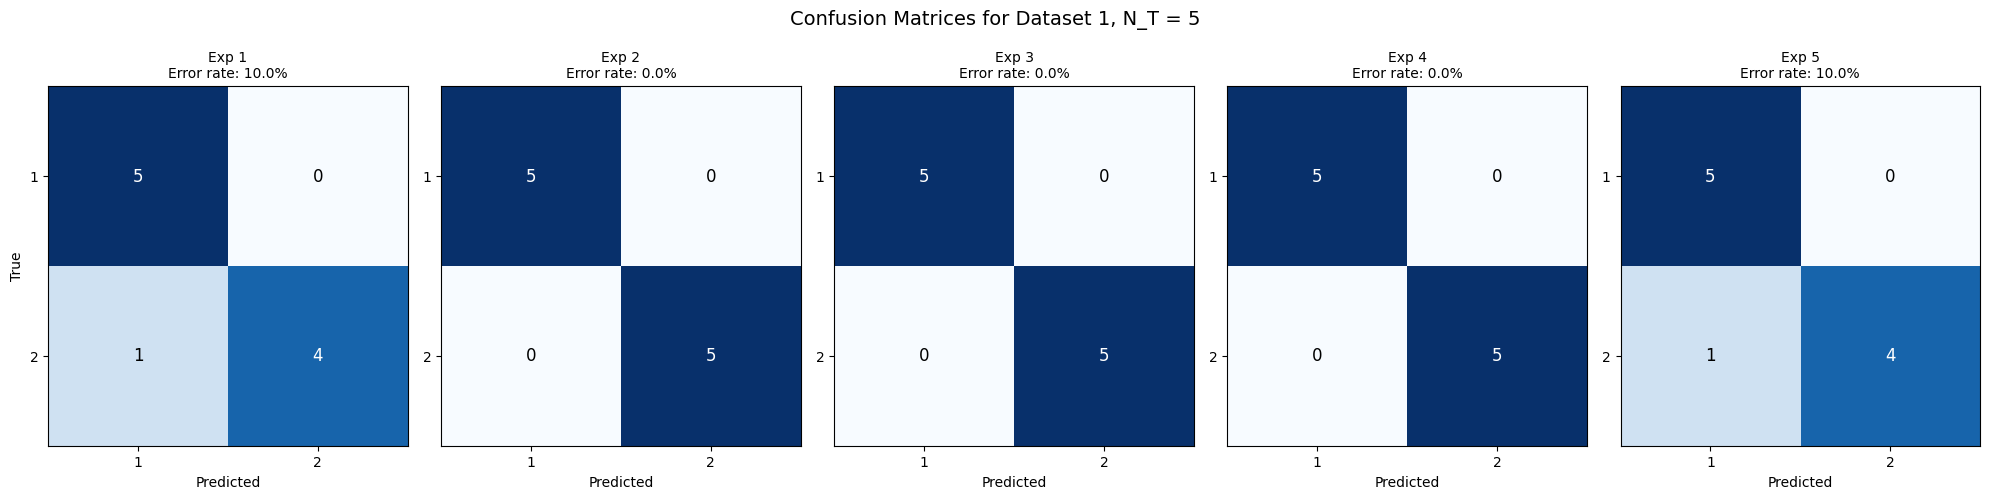

In [10]:
results_df_1 = {}

for NT in [5, 20, 100]:
    cms, rates, avg_cm, avg_error_rate = run_experiments_true_density(test_df_1, NT, num_experiments=5)
    results_df_1[NT] = {
        "confusion_matrices": cms,
        "error_rates": rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_error_rate
    }
       
plot_cms(results_df_1[5]["confusion_matrices"], results_df_1[5]["error_rates"], title_suffix = "Dataset 1, N_T = 5")

### Confusion matrices for NT = 20 and 100

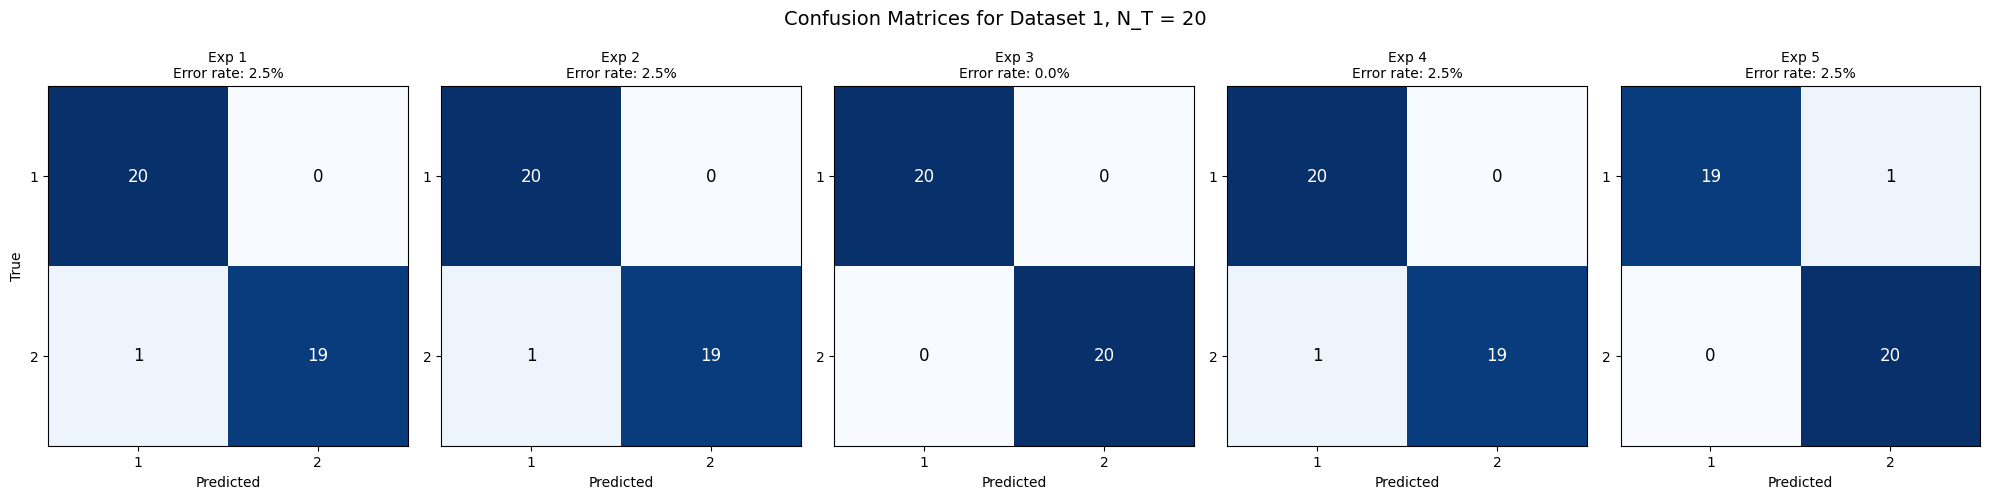

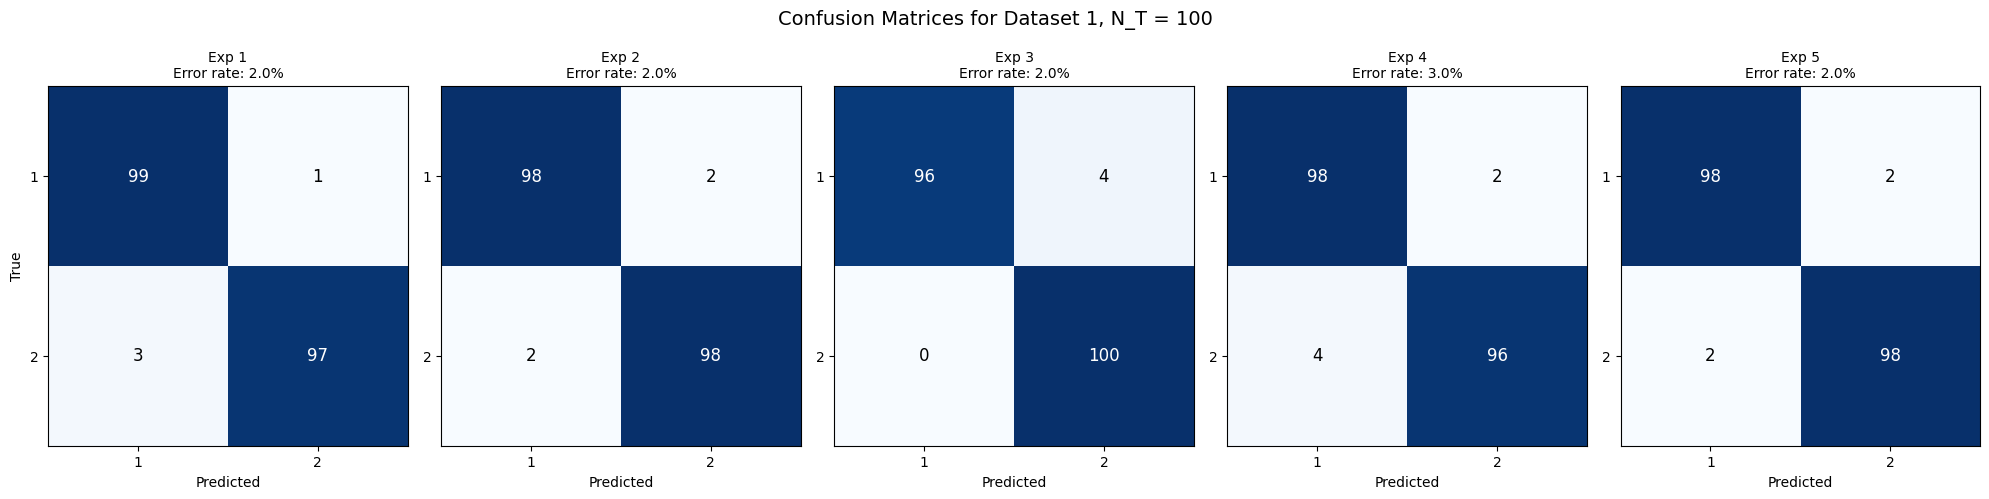

In [11]:
plot_cms(results_df_1[20]["confusion_matrices"], results_df_1[20]["error_rates"], title_suffix = "Dataset 1, N_T = 20")   
plot_cms(results_df_1[100]["confusion_matrices"], results_df_1[100]["error_rates"], title_suffix = "Dataset 1, N_T = 100")

### Averaged confusion matrix

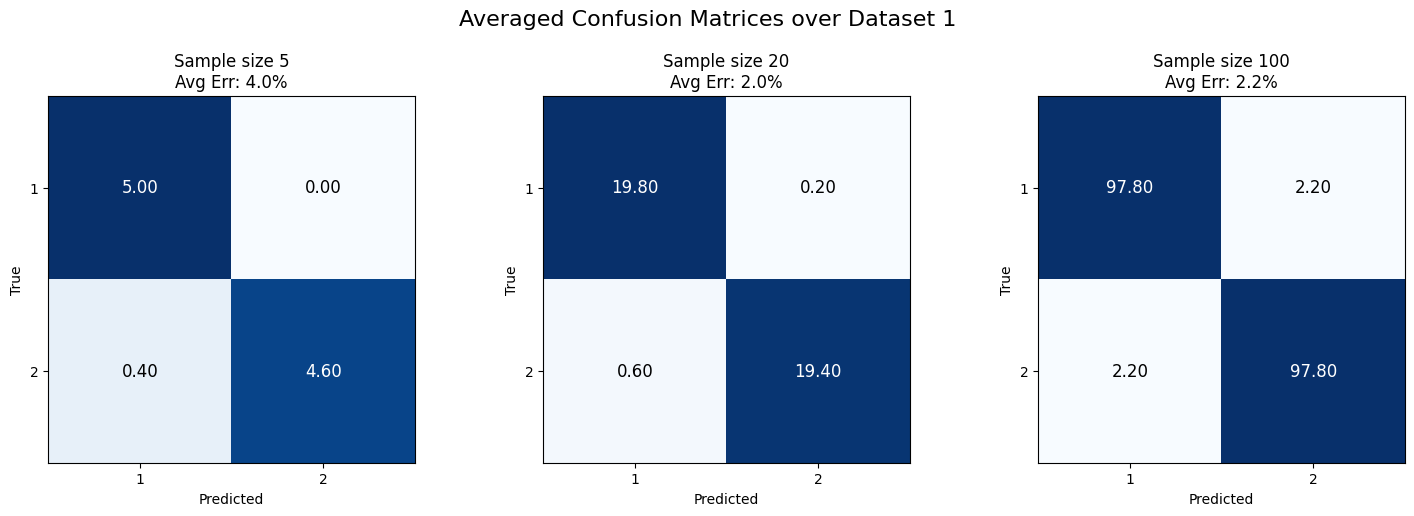

In [12]:
plot_avg_cm_all(results_df_1, title_suffix ="Dataset 1")

## (1d) Will the average error rate above differ from the error rate you would get if you used all the five test sets in one single test?

No.

Since we use the same classifer and the same number of samples from non-overlapping test sets, we should get the same overall error. In other words, the overall error rate is the total number of misclassifications divided by the total number of samples.

## Repeat for datasets 2 and 3

### Dataset 2 repeat

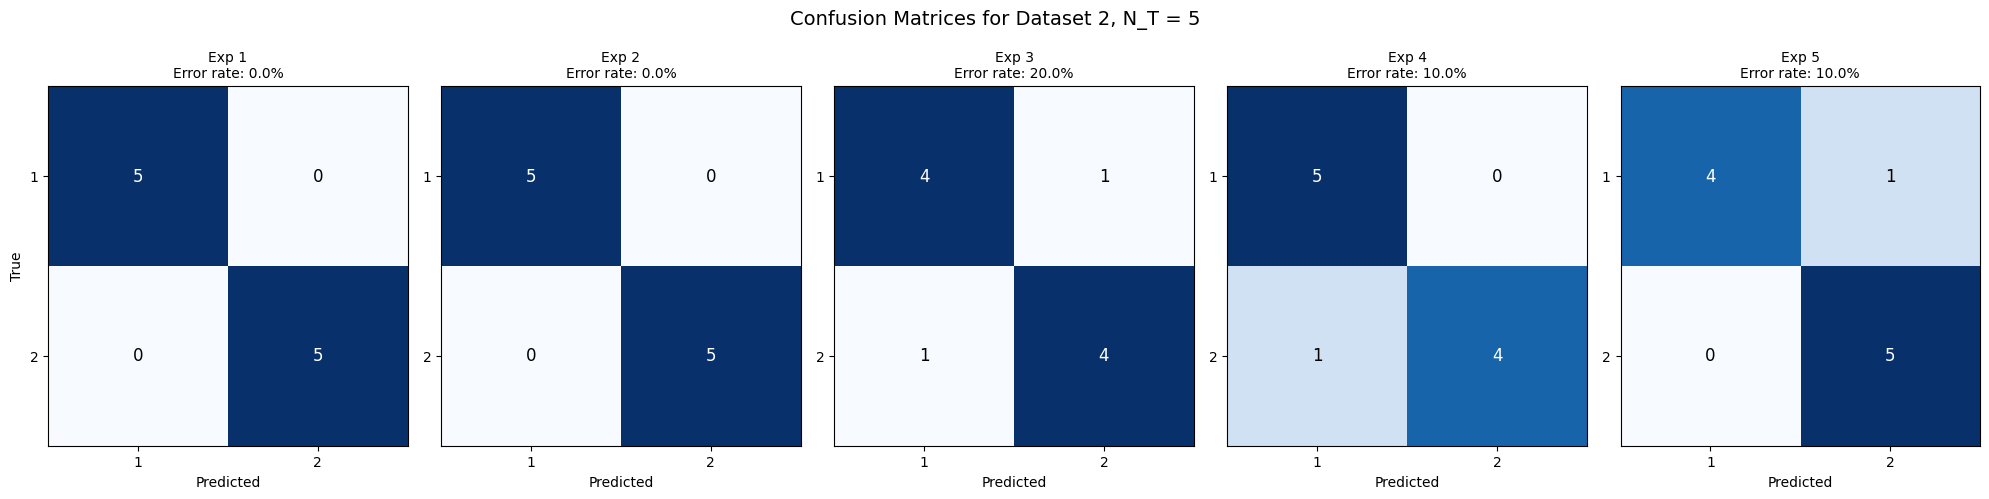

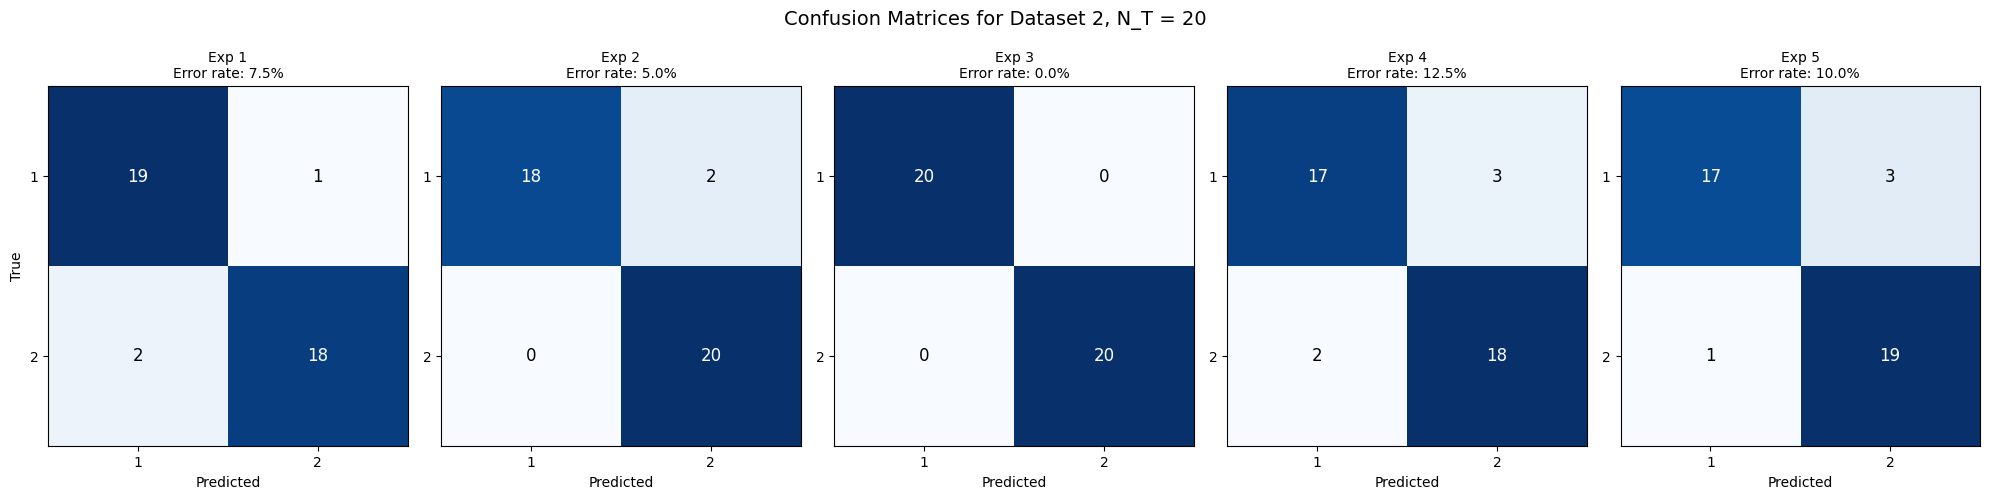

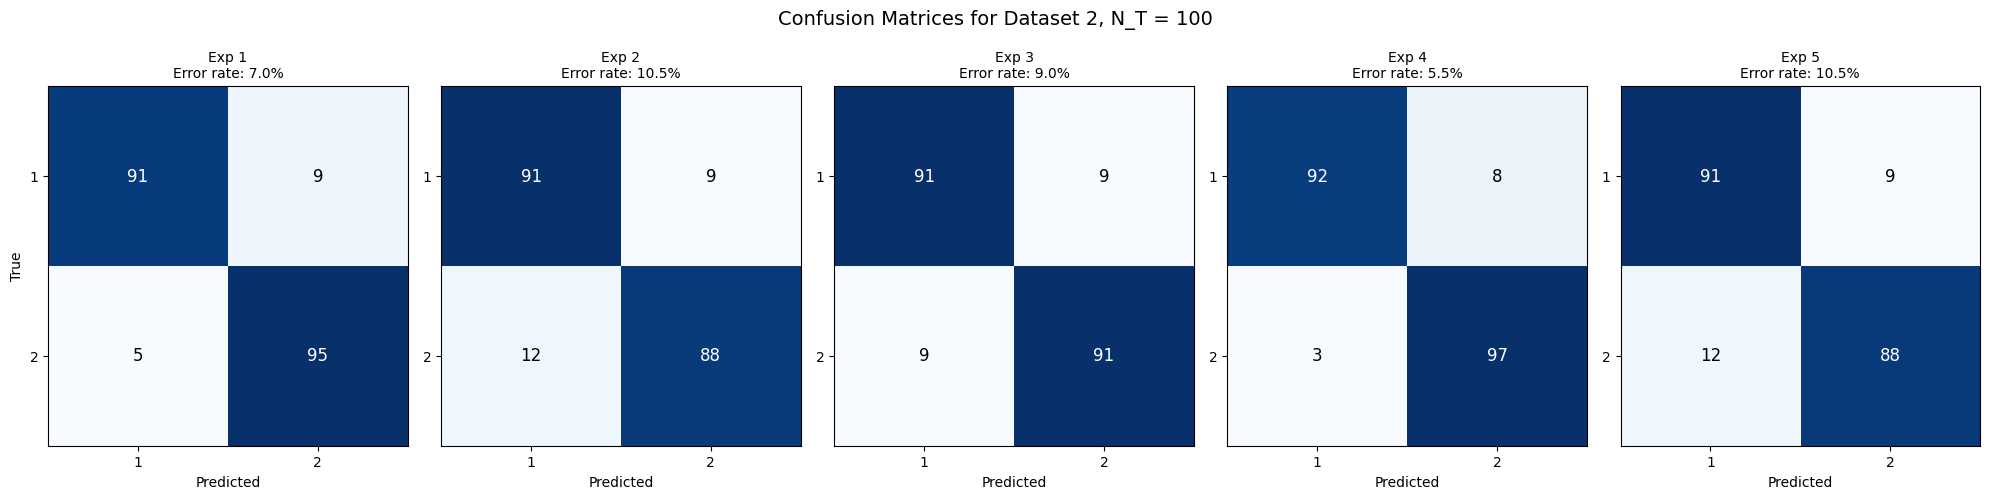

In [13]:
test_df_2 = df_2[df_2['Set'] == 'test'].copy()

results_df_2 = {}

for NT in [5, 20, 100]:
    cms, rates, avg_cm, avg_error_rate = run_experiments_true_density(test_df_2, NT, num_experiments=5)
    results_df_2[NT] = {
        "confusion_matrices": cms,
        "error_rates": rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_error_rate
    }
       
plot_cms(results_df_2[5]["confusion_matrices"], results_df_2[5]["error_rates"], title_suffix = "Dataset 2, N_T = 5")
plot_cms(results_df_2[20]["confusion_matrices"], results_df_2[20]["error_rates"], title_suffix = "Dataset 2, N_T = 20")   
plot_cms(results_df_2[100]["confusion_matrices"], results_df_2[100]["error_rates"], title_suffix = "Dataset 2, N_T = 100")

### Dataset 3 repeat

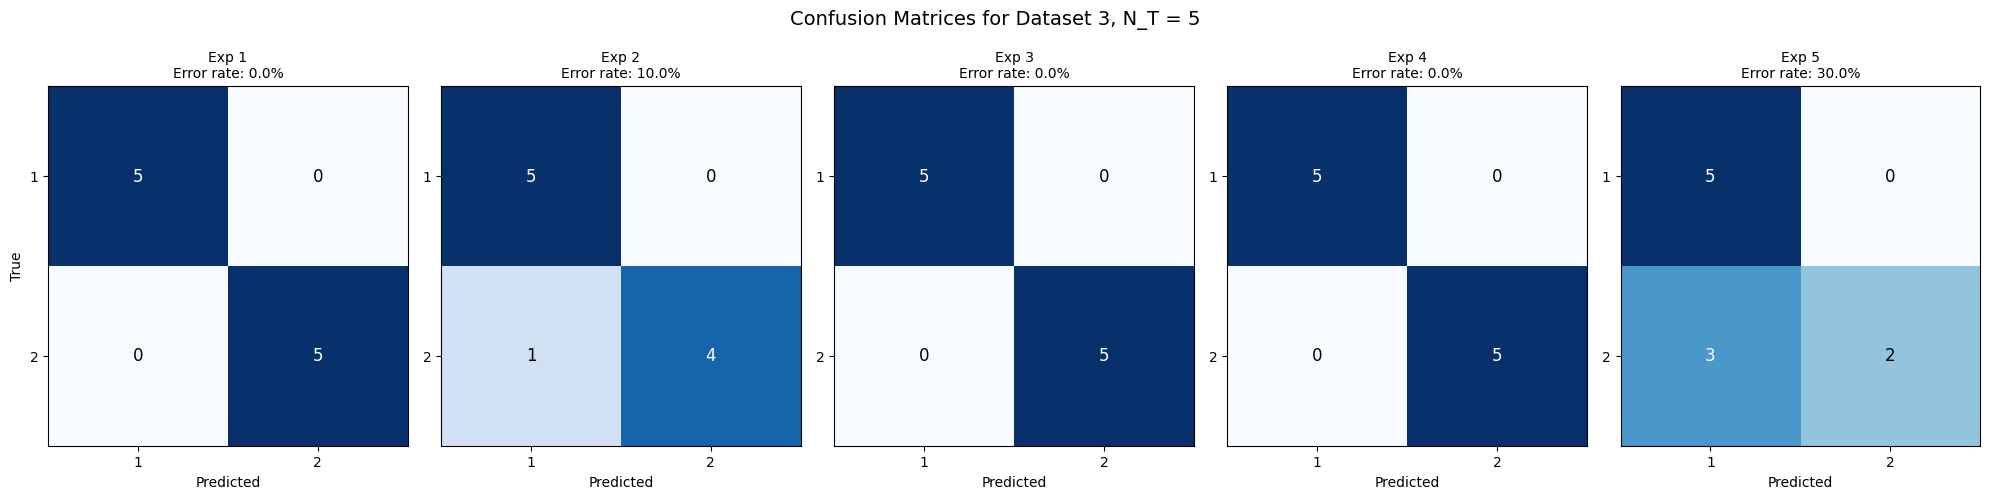

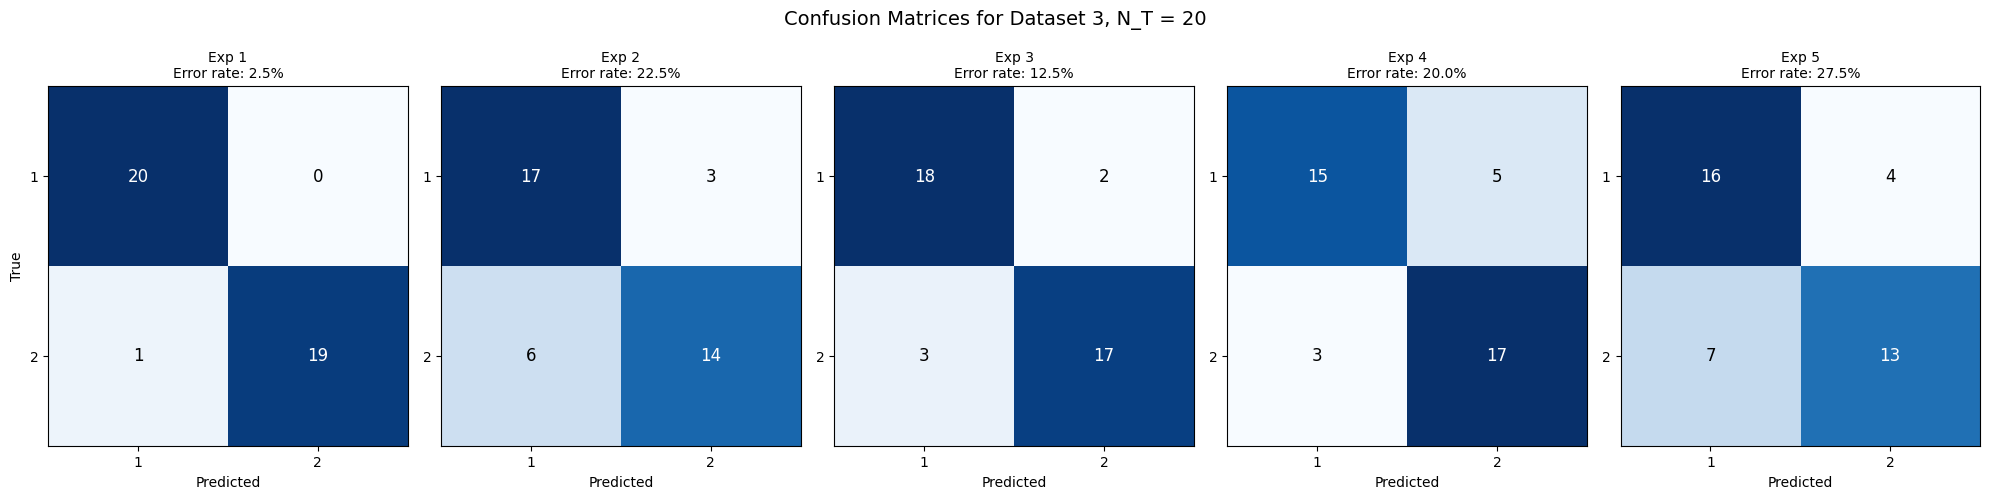

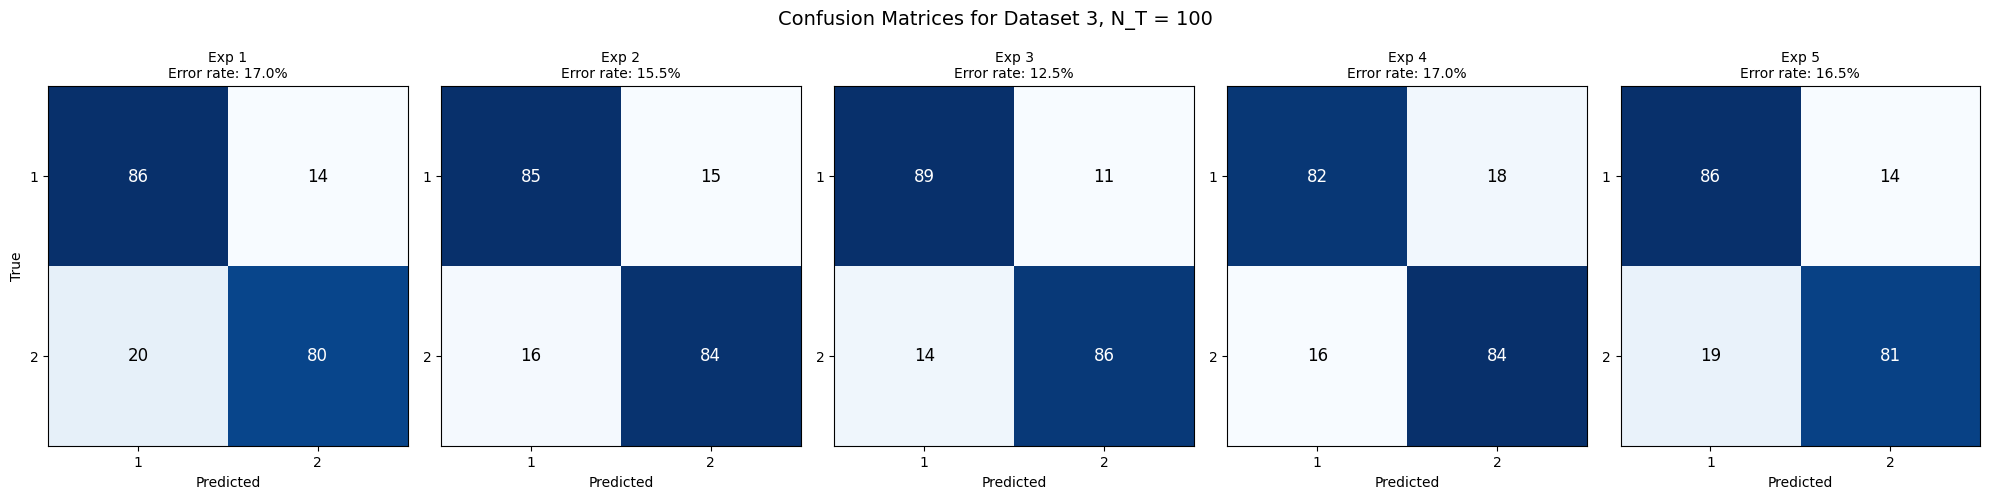

In [14]:
test_df_3 = df_3[df_3['Set'] == 'test'].copy()

results_df_3 = {}
for NT in [5, 20, 100]:
    cms, rates, avg_cm, avg_error_rate = run_experiments_true_density(test_df_3, NT, num_experiments=5)
    results_df_3[NT] = {
        "confusion_matrices": cms,
        "error_rates": rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_error_rate
    }
       
plot_cms(results_df_3[5]["confusion_matrices"], results_df_3[5]["error_rates"], title_suffix = "Dataset 3, N_T = 5")
plot_cms(results_df_3[20]["confusion_matrices"], results_df_3[20]["error_rates"], title_suffix = "Dataset 3, N_T = 20")   
plot_cms(results_df_3[100]["confusion_matrices"], results_df_3[100]["error_rates"], title_suffix = "Dataset 3, N_T = 100")

### Average confusion matrices for dataset 2 and 3

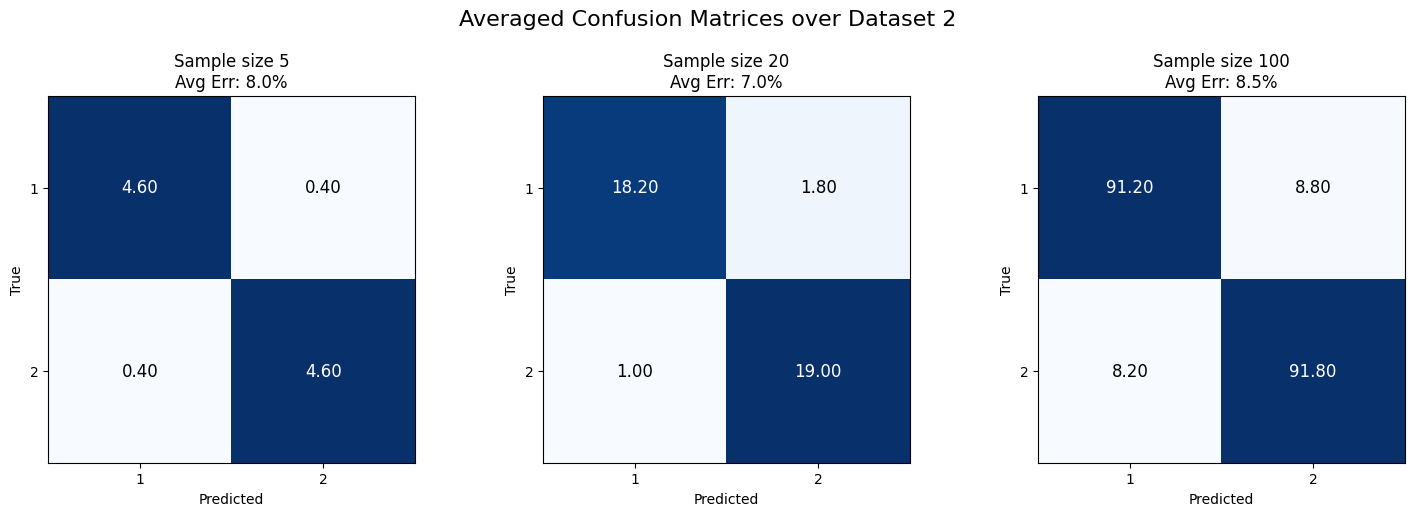

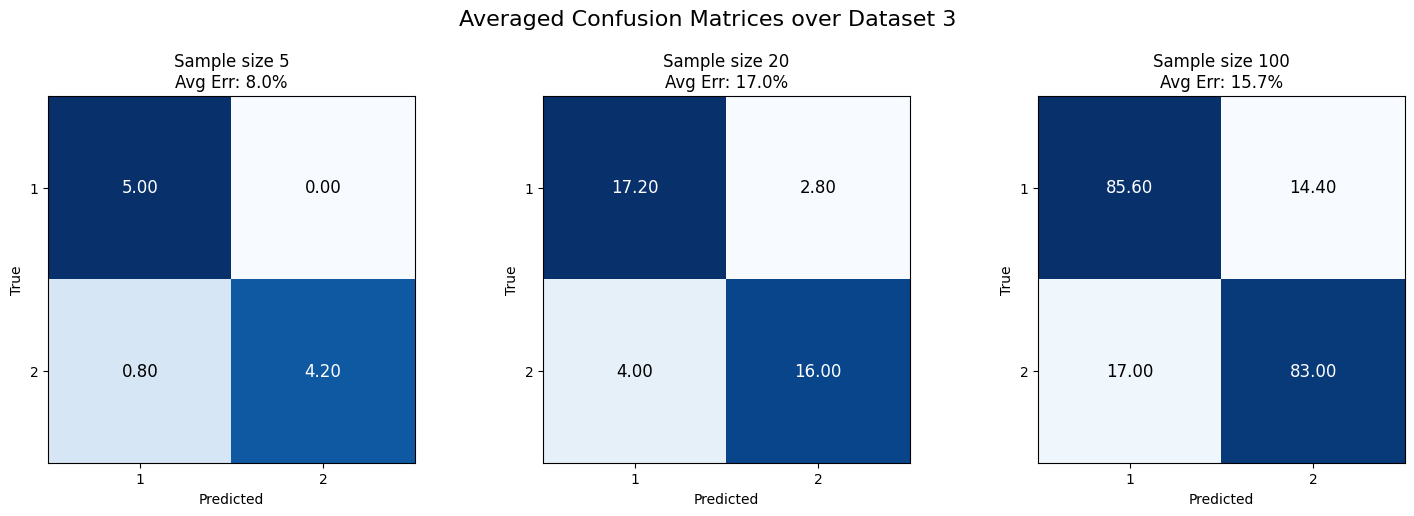

In [15]:
plot_avg_cm_all(results_df_2, title_suffix = "Dataset 2")
plot_avg_cm_all(results_df_3, title_suffix = "Dataset 3")

## What have we learned ?

$P_e^{\sigma^2= 0.25} = 2.28 \%, \qquad P_e^{\sigma^2= 0.49} = 7.66 \%, \qquad P_e^{\sigma^2= 1.00} = 15.87 $%

Avg($P_e^{\sigma^2= 0.25}$) Varied between 2 and 4 % 

Avg($P_e^{\sigma^2= 0.49}$) Varied between 7 and 8.5 % 

Avg($P_e^{\sigma^2= 1.00}$) Varied between 8 and 17 %

The matrices and the error rates dependent on the values of the randomly generated data; i.e. they vary beteween trials. This, combined with a finite test data size leads to the final error rates being both better and worse than the true error rates. $\textbf{However}$, the typically trend is that the variation decreases when increasing the sample length $N_T$, and we also see the same trend as for the true error rates, i.e. that the error rates decrease with decreasing class variance $\sigma^2$.



# Problem 2

In [16]:
# Define a function to compute the Gaussian likelihood for a scalar x.
def gaussian_likelihood(x, mu, sigma):
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-((x - mu)**2) / (2 * sigma**2))

In [17]:
def run_experiments_training(train_df, test_df, ND, num_experiments=5, seed=69):
    """
    For a given ND and number of experiments, this function partitions the 
    training set for each class into non-overlapping groups, estimates the
    mean and variance from each group and classifies all test samples and
    returns the confusion matrices and error rates for each experiment.
    """
    # Shuffle the training samples for each class (using a fixed seed for reproducibility)
    train_class1 = train_df[train_df['Class'] == 1].sample(frac=1, random_state=seed).reset_index(drop=True)
    train_class2 = train_df[train_df['Class'] == 2].sample(frac=1, random_state=seed).reset_index(drop=True)
    
    # Partition the training set into non-overlapping groups (ensure no reuse)
    groups_class1 = [train_class1.iloc[i*ND:(i+1)*ND] for i in range(num_experiments)]
    groups_class2 = [train_class2.iloc[i*ND:(i+1)*ND] for i in range(num_experiments)]
    
    confusion_matrices = []
    error_rates = []
    
    # For each experiment, train the classifier and test on all test samples.
    for i in range(num_experiments):
        # Estimate parameters from the ND training samples for each class
        mu1 = groups_class1[i]['Value'].mean()
        sigma1 = groups_class1[i]['Value'].std(ddof=0)  # use population standard deviation
        
        mu2 = groups_class2[i]['Value'].mean()
        sigma2 = groups_class2[i]['Value'].std(ddof=0)
        
        # Compute log-likelihoods for each test sample under each class:
        test_values = test_df['Value'].values
        
        loglik_1 = gaussian_likelihood(test_values, mu1, sigma1)
        loglik_2 = gaussian_likelihood(test_values, mu2, sigma2)
        
        # Predict: if loglik_1 > loglik_2, choose class 1; otherwise, choose class 2.
        y_pred = np.where(loglik_1 > loglik_2, 1, 2)
        y_true = test_df['Class'].values
        
        # Compute confusion matrix (with labels [1,2] to preserve ordering)
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        confusion_matrices.append(cm)
        
        # Compute error rate.
        error_rate = np.mean(y_true != y_pred)
        error_rates.append(error_rate)
    
    # Compute average confusion matrix (elementwise average) and average error rate over experiments
    avg_cm = sum(confusion_matrices) / num_experiments
    avg_error_rate = np.mean(error_rates)
    
    return confusion_matrices, error_rates, avg_cm, avg_error_rate

## Train dataset 1

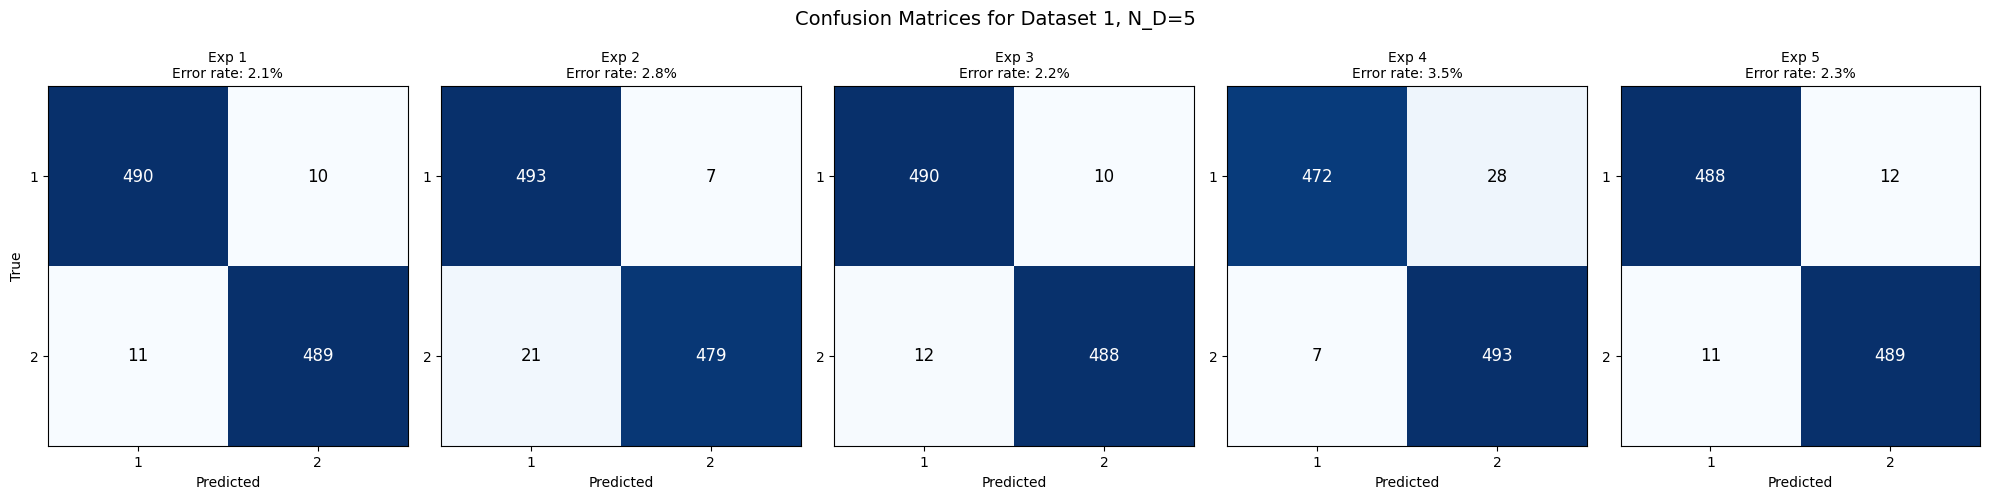

In [18]:
train_df_1 = df_1[df_1['Set'] == 'train'].copy()
test_df_1  = df_1[df_1['Set'] == 'test'].copy()

results_train_df_1 = {}
for ND in [5, 20, 100]:
    cms, err_rates, avg_cm, avg_err_rate = run_experiments_training(train_df_1, test_df_1, ND, num_experiments=5, seed=69)
    results_train_df_1[ND] = {
        "confusion_matrices": cms,
        "error_rates": err_rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_err_rate
    }
plot_cms(results_train_df_1[5]["confusion_matrices"], results_train_df_1[5]["error_rates"], title_suffix = "Dataset 1, N_D=5")

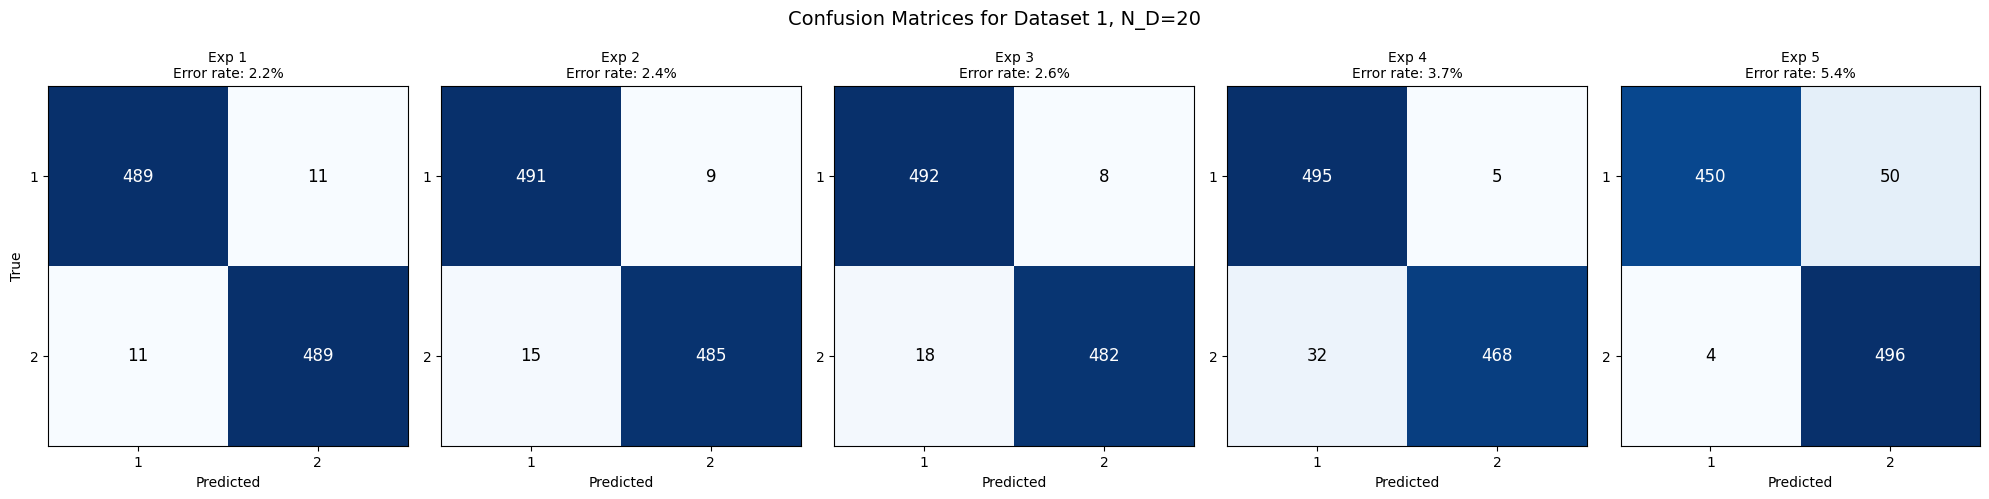

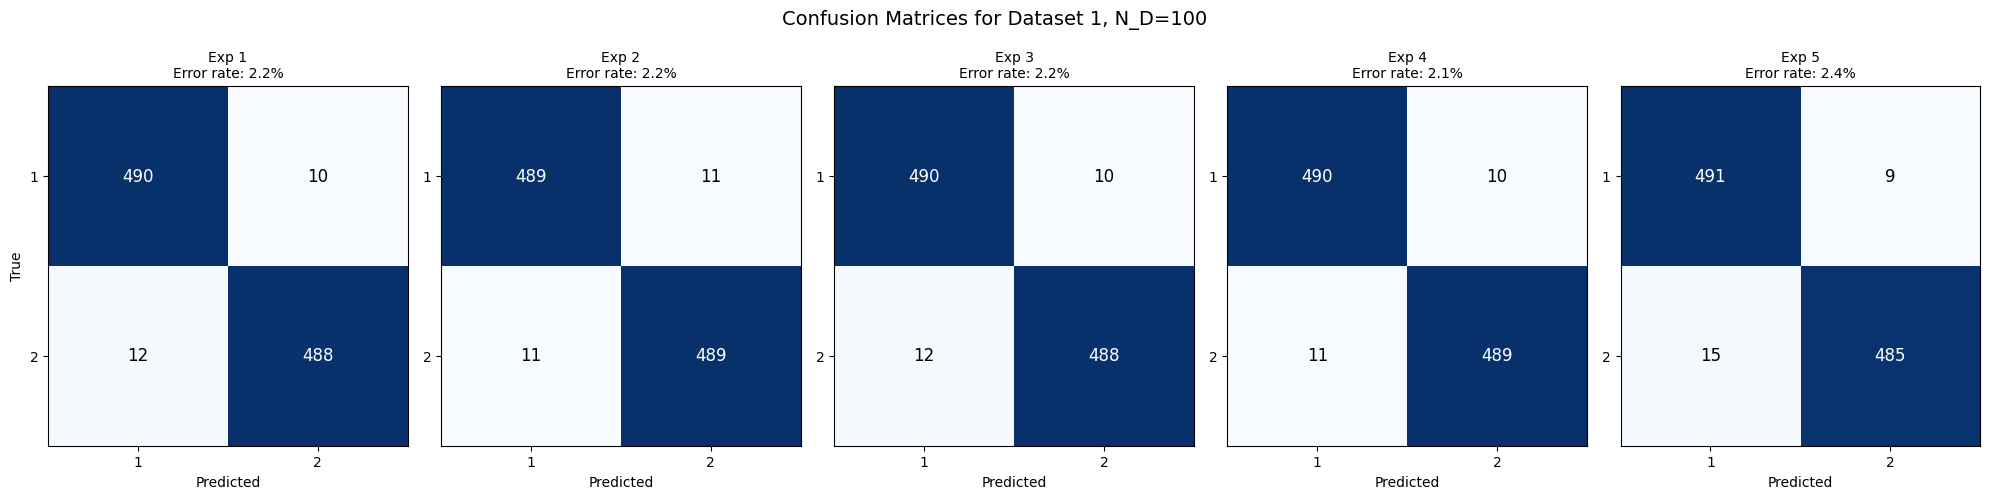

In [19]:
plot_cms(results_train_df_1[20]["confusion_matrices"], results_train_df_1[20]["error_rates"], title_suffix = "Dataset 1, N_D=20")
plot_cms(results_train_df_1[100]["confusion_matrices"], results_train_df_1[100]["error_rates"], title_suffix = "Dataset 1, N_D=100")

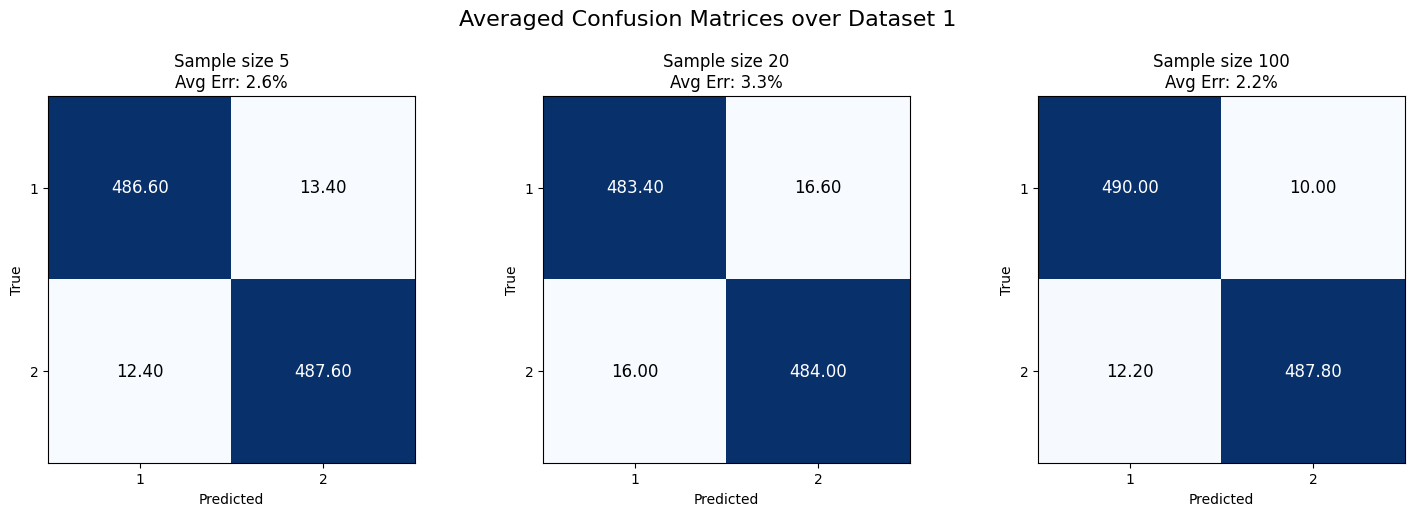

In [20]:
plot_avg_cm_all(results_train_df_1, title_suffix = "Dataset 1")

## What have we learned?
When using a small amount sample size $N_D$ of the training data (and no "reuse"), we see a large
variation in test error rates and confusion matrixes for the five different runs. As the size increases however, the differences gets smaller and the errors thus lower. Furhtermore, the estimated model parameters vary more for lower sample sizes.

## Repeat computations dataset 2 and 3

### Train dataset 2

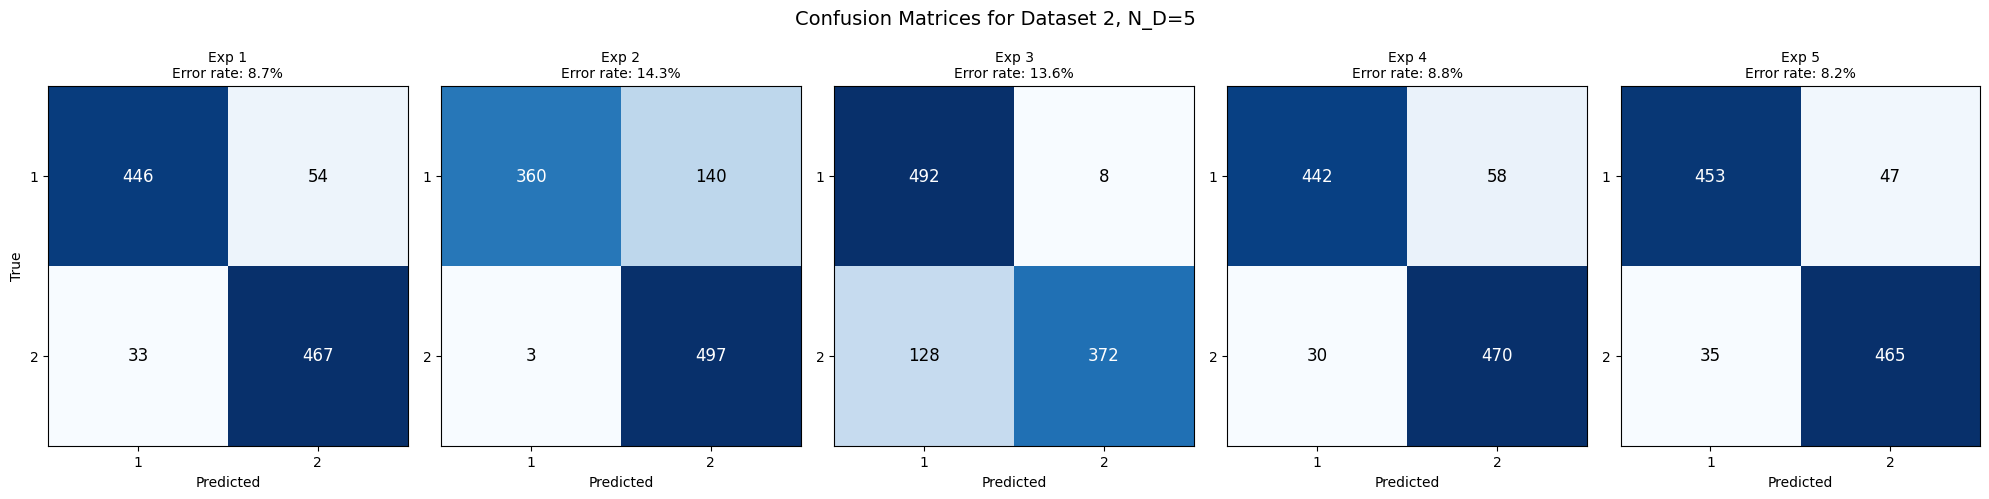

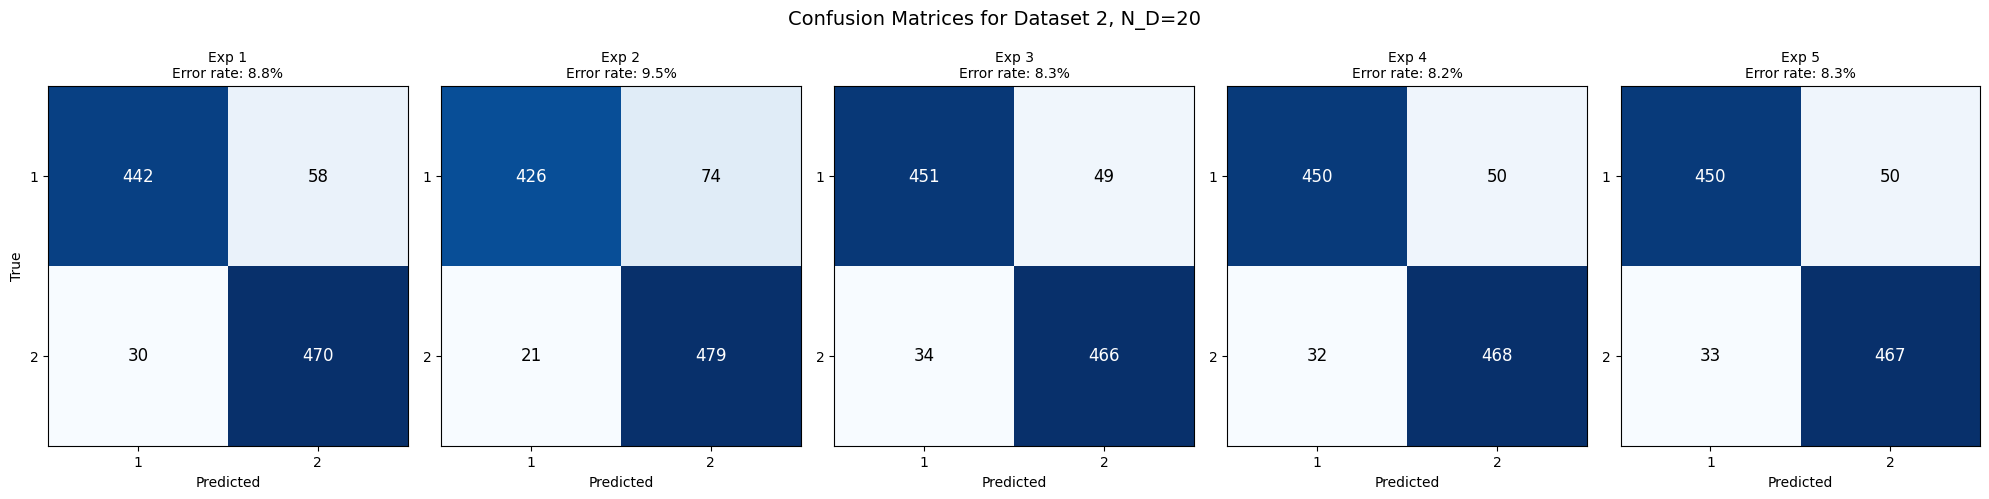

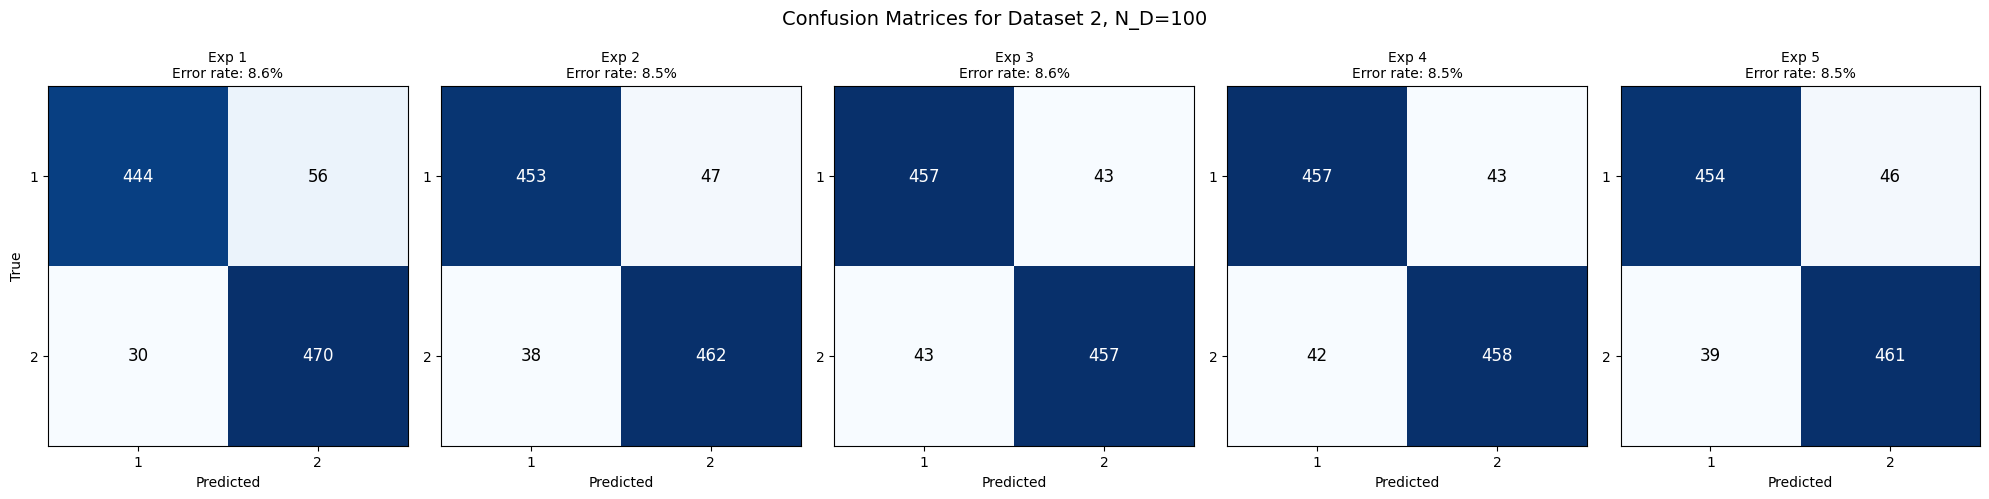

In [21]:
train_df_2 = df_2[df_2['Set'] == 'train'].copy()
test_df_2  = df_2[df_2['Set'] == 'test'].copy()

results_train_df_2 = {}

for ND in [5, 20, 100]:
    cms, err_rates, avg_cm, avg_err_rate = run_experiments_training(train_df_2, test_df_2, ND, num_experiments=5, seed=69)
    results_train_df_2[ND] = {
        "confusion_matrices": cms,
        "error_rates": err_rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_err_rate
    }
    
plot_cms(results_train_df_2[5]["confusion_matrices"], results_train_df_2[5]["error_rates"], title_suffix = "Dataset 2, N_D=5")
plot_cms(results_train_df_2[20]["confusion_matrices"], results_train_df_2[20]["error_rates"], title_suffix = "Dataset 2, N_D=20")   
plot_cms(results_train_df_2[100]["confusion_matrices"], results_train_df_2[100]["error_rates"], title_suffix = "Dataset 2, N_D=100")

### Train with dataset 3

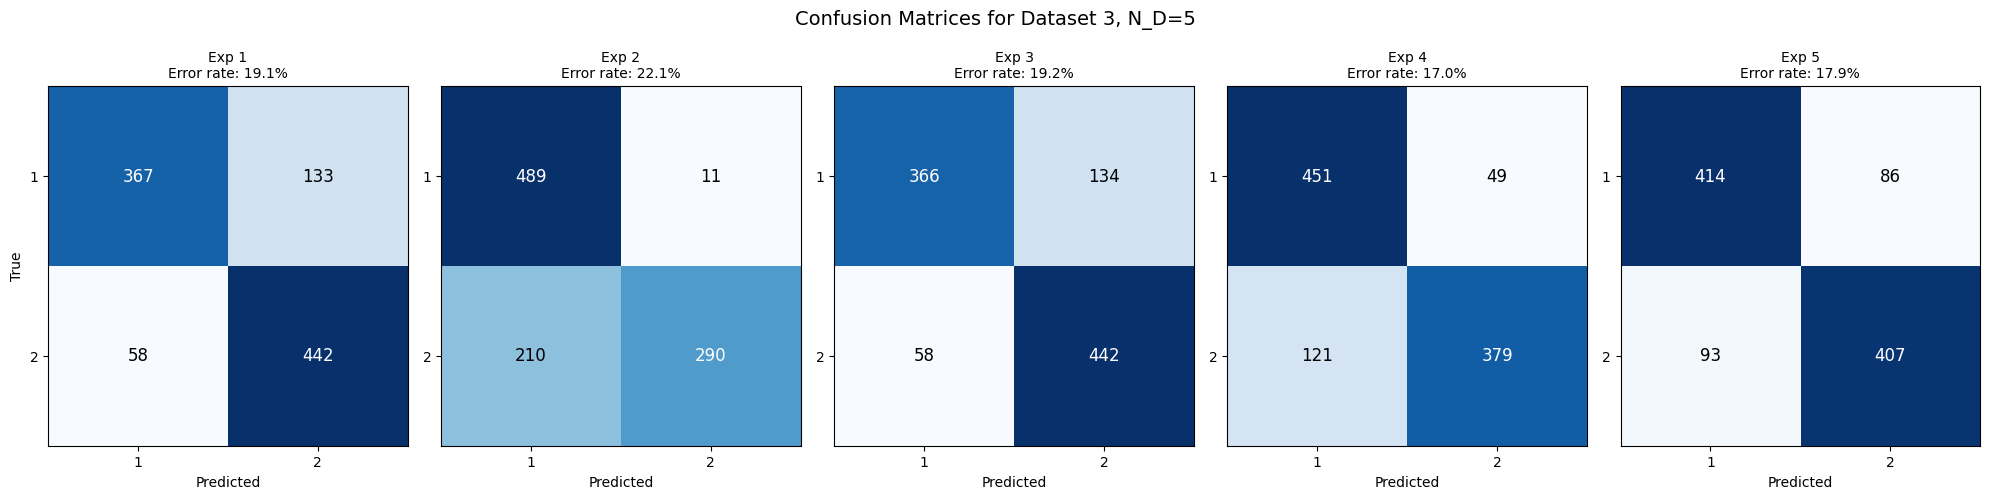

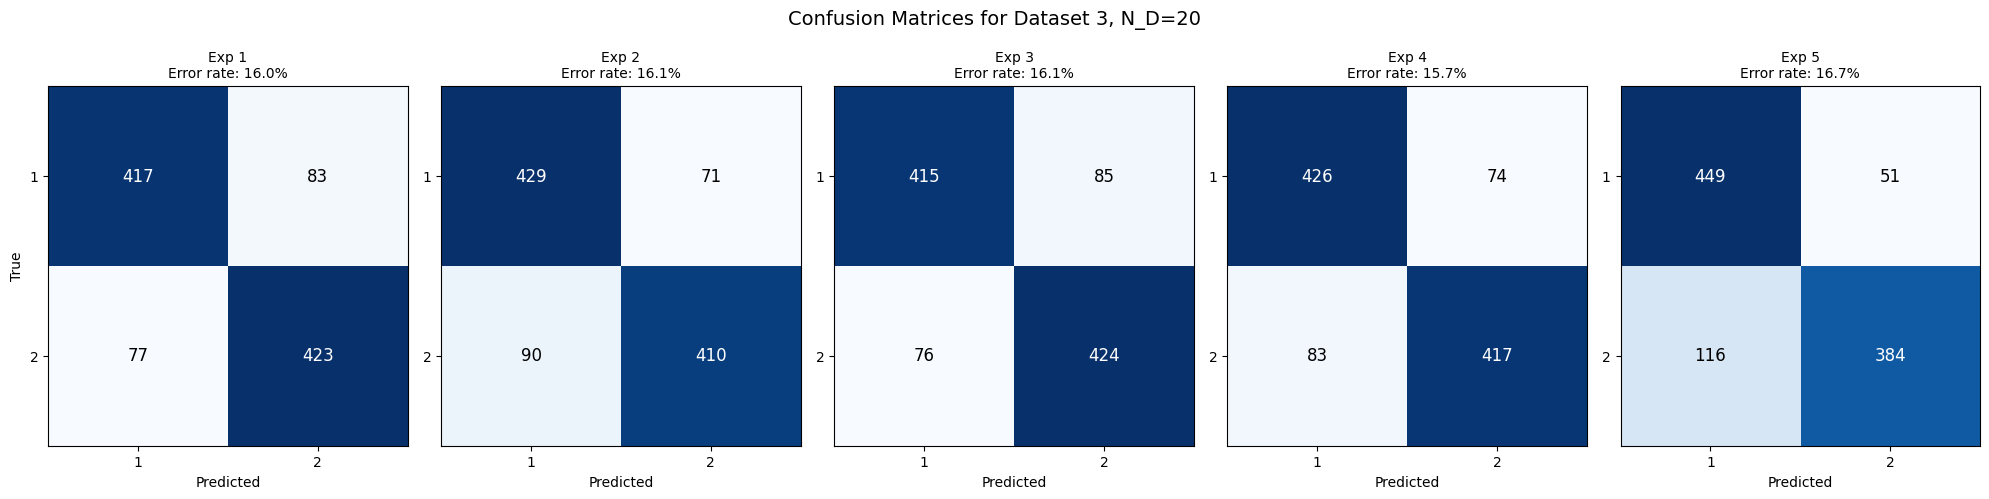

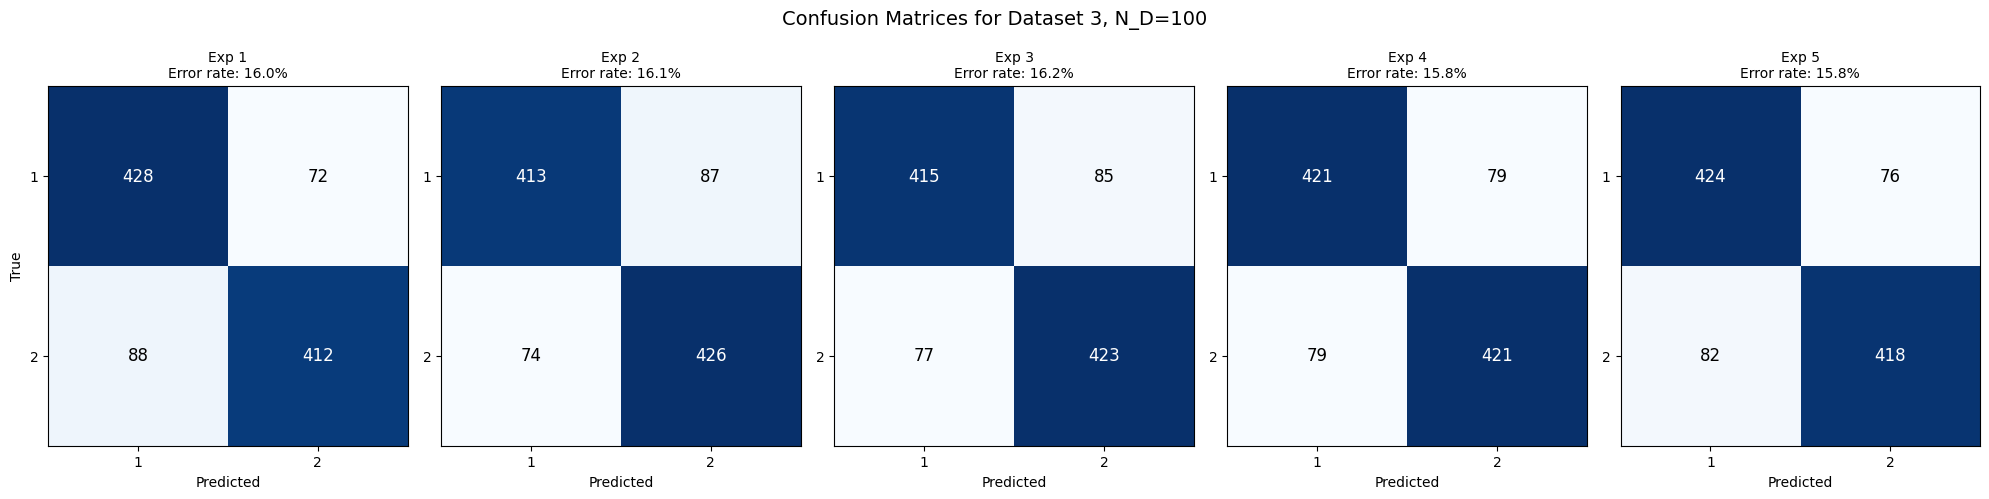

In [22]:
train_df_3 = df_3[df_3['Set'] == 'train'].copy()
test_df_3  = df_3[df_3['Set'] == 'test'].copy()

results_train_df_3 = {}

for ND in [5, 20, 100]:
    cms, err_rates, avg_cm, avg_err_rate = run_experiments_training(train_df_3, test_df_3, ND, num_experiments=5, seed=69)
    results_train_df_3[ND] = {
        "confusion_matrices": cms,
        "error_rates": err_rates,
        "avg_confusion_matrix": avg_cm,
        "avg_error_rate": avg_err_rate
    }
    
plot_cms(results_train_df_3[5]["confusion_matrices"], results_train_df_3[5]["error_rates"], title_suffix = "Dataset 3, N_D=5")
plot_cms(results_train_df_3[20]["confusion_matrices"], results_train_df_3[20]["error_rates"], title_suffix = "Dataset 3, N_D=20")   
plot_cms(results_train_df_3[100]["confusion_matrices"], results_train_df_3[100]["error_rates"], title_suffix = "Dataset 3, N_D=100")

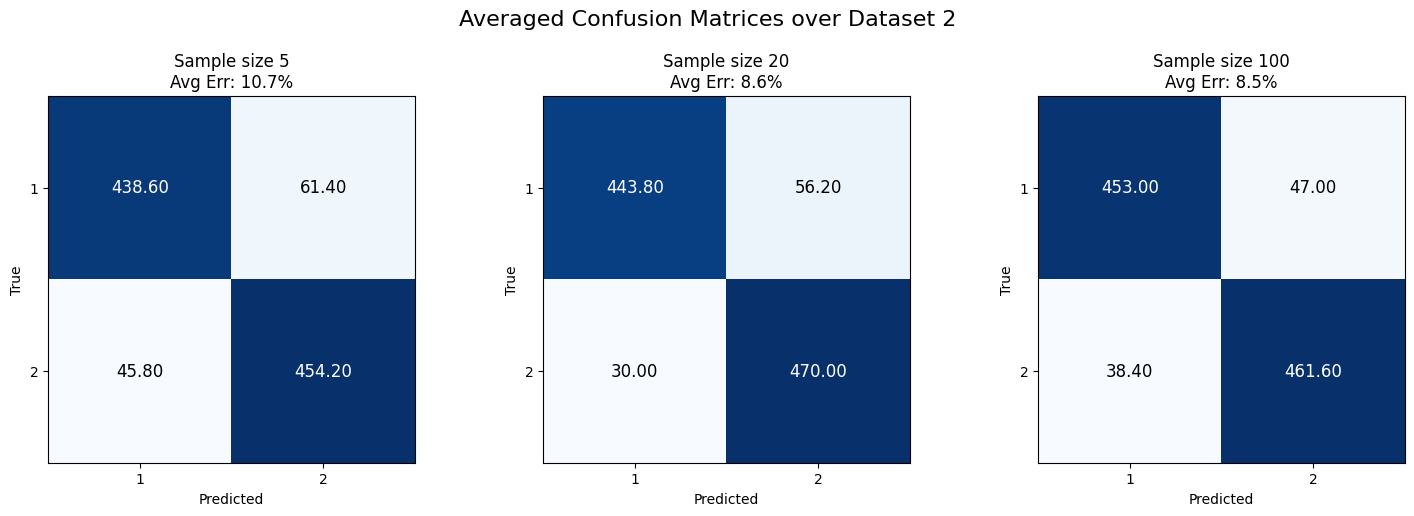

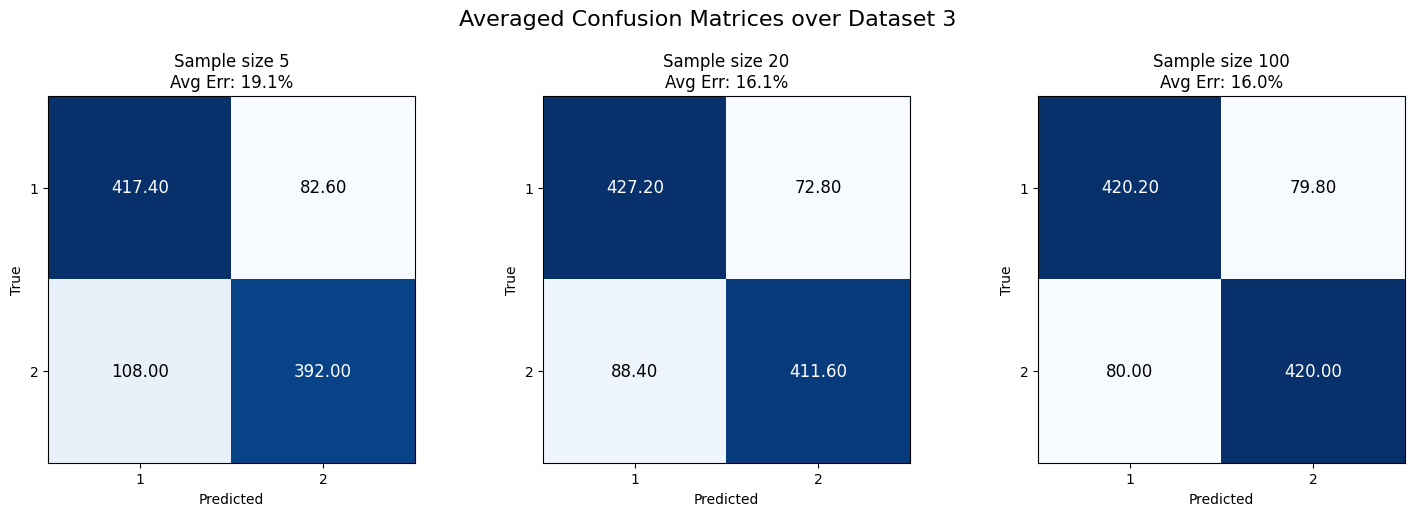

In [23]:
plot_avg_cm_all(results_train_df_2, title_suffix = "Dataset 2")
plot_avg_cm_all(results_train_df_3, title_suffix = "Dataset 3")

## (2b) Will this error rate differ from the error rate you would get if you used all the five training sets in one single training?

Yes.

In this setting we have different models for each run and combining all five sets would thus result in a sixth model, and thus a different error rate then the averag of the other five. 

# Problem 3 - Investigate the **leave-one-out** procedure

In [24]:
def run_leave_one_out(training_df, seed=69):
    """
    Performs leave-one-out testing on the first 6 samples from each class.
    Take one sample out, train on the remaining 5 samples per class, then
    classify the test samples and return compute the confusionmatrix and error rate.
    """
    # Extract the first 6 samples for each class.
    class1_all = training_df[training_df['Class'] == 1].iloc[:6].reset_index(drop=True)
    class2_all = training_df[training_df['Class'] == 2].iloc[:6].reset_index(drop=True)
    
    confusion_matrices = []
    error_rates = []
    
    # Loop over the 6 leave-one-out experiments.
    for i in range(6):
        # For class 1: leave out the i-th sample as test, train on the others.
        train_class1 = class1_all.drop(i).reset_index(drop=True)
        test_sample1 = class1_all.iloc[i]['Value']
        
        # For class 2: leave out the i-th sample as test, train on the others.
        train_class2 = class2_all.drop(i).reset_index(drop=True)
        test_sample2 = class2_all.iloc[i]['Value']
        
        # Estimate Gaussian parameters for class 1 from 5 training samples.
        mu1 = train_class1['Value'].mean()
        sigma1 = train_class1['Value'].std(ddof=0)  # population std
        
        # Estimate Gaussian parameters for class 2 from 5 training samples.
        mu2 = train_class2['Value'].mean()
        sigma2 = train_class2['Value'].std(ddof=0)
        
        
        # Compute likelihoods for each test sample under each class's model.
        # For test_sample1:
        like1_sample1 = gaussian_likelihood(test_sample1, mu1, sigma1)
        like2_sample1 = gaussian_likelihood(test_sample1, mu2, sigma2)
        
        # For test_sample2:
        like1_sample2 = gaussian_likelihood(test_sample2, mu1, sigma1)
        like2_sample2 = gaussian_likelihood(test_sample2, mu2, sigma2)
        
        # Predict: For each sample, choose the class with the higher likelihood.
        # Sample1:
        pred1 = 1 if like1_sample1 > like2_sample1 else 2
        # Sample2:
        pred2 = 1 if like1_sample2 > like2_sample2 else 2
        
        y_pred = np.array([pred1, pred2])
        y_true = np.array([1, 2])
        
        # Compute confusion matrix (ensuring order [1, 2])
        cm = confusion_matrix(y_true, y_pred, labels=[1, 2])
        confusion_matrices.append(cm)
        
        # Compute error rate (over 2 test samples)
        error_rate = np.mean(y_true != y_pred)
        error_rates.append(error_rate)
    
    # Compute the average confusion matrix and average error rate over the 6 experiments.
    avg_cm = sum(confusion_matrices) / 6
    avg_error_rate = np.mean(error_rates)
    
    return confusion_matrices, error_rates, avg_cm, avg_error_rate


In [25]:
def plot_combined_avg_cm(avg_cm1, avg_err1, avg_cm2, avg_err2, title_label1="Leave-one-out", title_label2="Training"):
    """
    Creates one figure with two subplots showing the average confusion matrices.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # First subplot
    ax = axes[0]
    im = ax.imshow(avg_cm1, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Average Confusion Matrix\nAvg Err: {avg_err1*100:.1f}%\n({title_label1})', fontsize=12)
    for i in range(avg_cm1.shape[0]):
        for j in range(avg_cm1.shape[1]):
            threshold = avg_cm1.max() / 2.0
            cell_value = avg_cm1[i, j]
            text_color = "white" if cell_value > threshold else "black"
            ax.text(j, i, f'{cell_value:.1f}', ha="center", va="center", color=text_color, fontsize=12)

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels([1, 2])
    ax.set_yticklabels([1, 2])
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    
    # Second subplot
    ax = axes[1]
    im = ax.imshow(avg_cm2, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'Average Confusion Matrix\nAvg Err: {avg_err2*100:.1f}%\n({title_label2})', fontsize=12)
    for i in range(avg_cm2.shape[0]):
        for j in range(avg_cm2.shape[1]):
            threshold = avg_cm2.max() / 2.0
            cell_value = avg_cm2[i, j]
            text_color = "white" if cell_value > threshold else "black"
            ax.text(j, i, f'{cell_value:.1f}', ha="center", va="center", color=text_color, fontsize=12)

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels([1, 2])
    ax.set_yticklabels([1, 2])
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    
    fig.suptitle("Combined Average Confusion Matrices", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


## Dataset 1

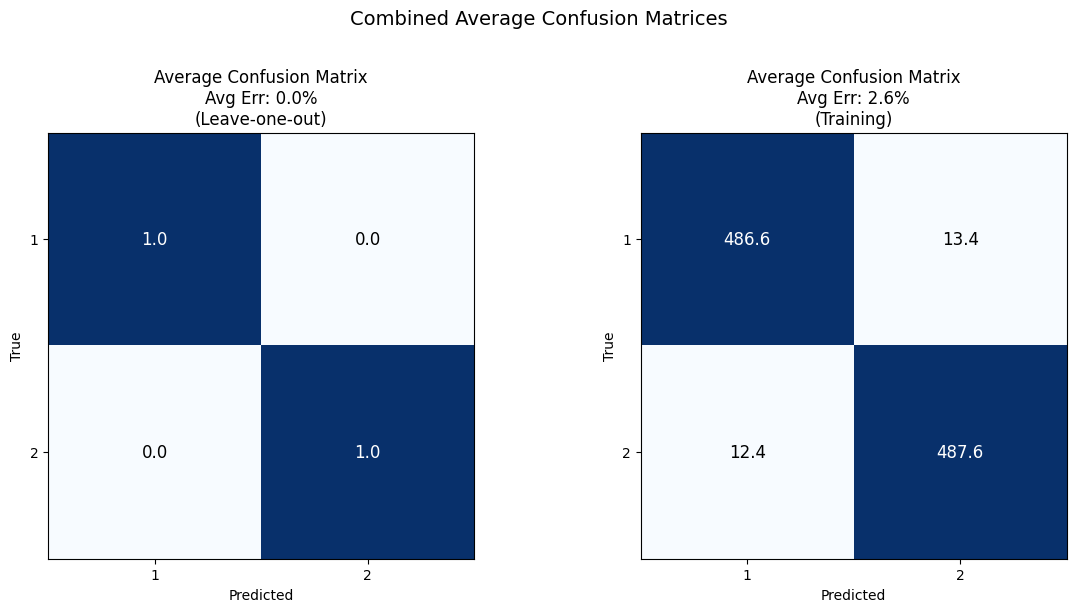

In [26]:
cms_1, err_rates_1, avg_cm_1, avg_err_1 = run_leave_one_out(train_df_1)

plot_combined_avg_cm(avg_cm_1, avg_err_1,
                     results_train_df_1[5]["avg_confusion_matrix"],
                     results_train_df_1[5]["avg_error_rate"],
                     title_label1="Leave-one-out",
                     title_label2="Training")

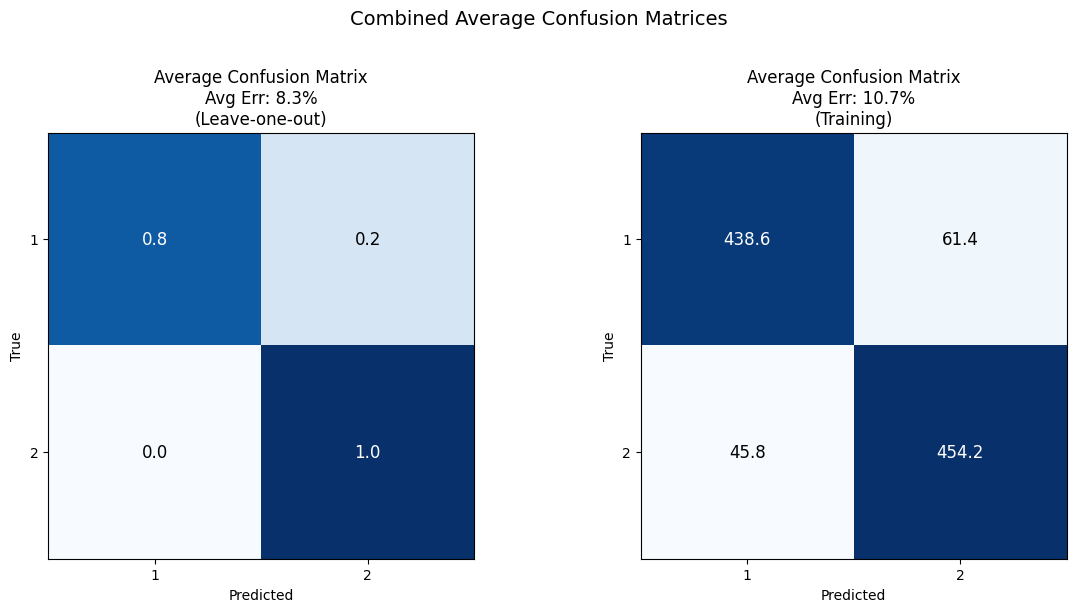

In [27]:
cms_2, err_rates_2, avg_cm_2, avg_err_2 = run_leave_one_out(train_df_2)

plot_combined_avg_cm(avg_cm_2, avg_err_2,
                     results_train_df_2[5]["avg_confusion_matrix"],
                     results_train_df_2[5]["avg_error_rate"],
                     title_label1="Leave-one-out",
                     title_label2="Training")

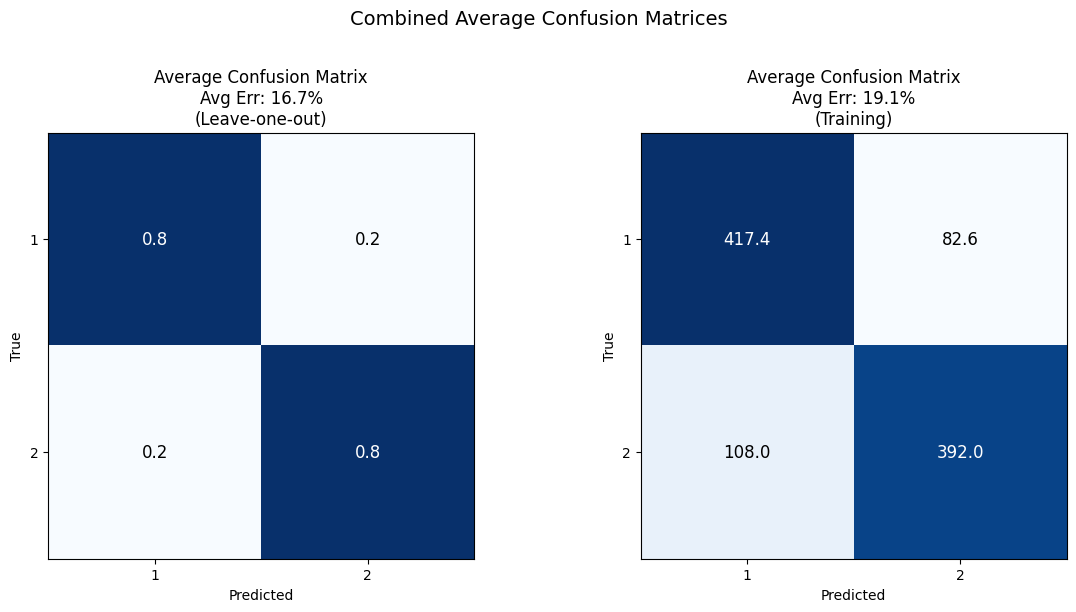

In [28]:
cms_3, err_rates_3, avg_cm_3, avg_err_3 = run_leave_one_out(train_df_3)

plot_combined_avg_cm(avg_cm_3, avg_err_3,
                     results_train_df_3[5]["avg_confusion_matrix"],
                     results_train_df_3[5]["avg_error_rate"],
                     title_label1="Leave-one-out",
                     title_label2="Training")

## Comparing with previous classifier
The leave-one-out models have a lower average error rate than the model based on different subsets of five samples from problem 2, with $N_D = 5$ for all three datasets. The error rate is sitll higher for the datasets with larger variance.

Leave-one-out maximizes the use of available data - very good for small datasets!